# Chemprop v2 — Experiment 2: CIP R/S Featurization (No Parity Tag)

This notebook replaces Chemprop's default `ChiralTag` (`@`/`@@` SMILES parity) atom
feature with the **CIP absolute stereochemistry label** (R/S/r/s). The `@`/`@@` parity
tag is removed entirely from the atom feature vector — the MPNN sees only the CIP code
and molecular topology.

**Motivation:** background analysis (see `reference/`) showed that the `@`/`@@` parity tag does NOT map to
absolute stereochemistry — CW maps to R ~50% and S ~50% of the time across 1.23M
molecules. CIP R/S is the chemically meaningful descriptor. This experiment tests whether
encoding R/S directly improves prediction of stereochemistry-dependent properties.

**Implementation:** a self-contained `CIPAtomFeaturizer` is defined in this notebook. It
deliberately does **not** subclass or import chemprop's `MultiHotAtomFeaturizer`, so this
notebook remains a standalone demonstration of `@/@@` vs. CIP R/S featurization regardless
of how chemprop's internals change in future versions. The chiral block encodes CIP labels as a one-hot:

| Slot | Meaning |
|---|---|
| 0 | Achiral (no stereocenter) |
| 1 | R |
| 2 | S |
| 3 | r (pseudo-asymmetric) |
| 4 | s (pseudo-asymmetric) |
| 5 | Unknown pad (unexpected CIP value) |

Requires `rdCIPLabeler.AssignCIPLabels(mol)` before featurization.

**Conditions:**

| Condition | Type | Description |
|---|---|---|
| `exp_2_cip_rs_singletask` | Single-task | CIP R/S featurizer, independent model per target |
| `exp_2_cip_rs_multitask` | Multi-task | CIP R/S featurizer, joint 3-target model |

Singletask 1 x 3 targets x 5 folds = 15 fits; multitask 5 fits; **20 total.**

**Hypotheses tested:**
1. R/S should be the easiest target (inverse of Exp 1), because CIP R/S is encoded directly.
2. `@`/`@@` should be harder than Exp 1 (direct ChiralTag signal is removed).
3. F/L should improve over Exp 1, because F/L depends on absolute stereochemistry (R/S),
   not relative parity (`@`/`@@`).

> R/S here in Exp 2 (and `@/@@` in Exp 1) are positive
> control since the atom feature *is* the label. **F/L is the only genuinely predictive
> target** and is the number that should drive any configuration decision.

---

Part of series: `3_RF_morgan_count.ipynb` -> `4_chemprop_exp_0.ipynb` ->
`4_chemprop_exp_1.ipynb` -> **`4_chemprop_exp_2.ipynb`**


## Imports

**On warning filters.** Previous drafts used `warnings.filterwarnings('ignore', category=UserWarning)`, but this can hide useful warnings e.g., if a shuffled dataloader is accidentally used for prediction, Lightning warns via `PossibleUserWarning`, whose MRO is
`(PossibleUserWarning, UserWarning, Warning, ...)`, so blanket-ignoring `UserWarning`
silences it. This notebook filters only four specific messages, each verified as benign:
- dataloader worker counts
- a torch pytree deprecation
- Lightning declining to YAML-dump the `metrics` parameter
- MPS nondeterminism (see Configuration)

In [1]:
import chemprop

In [2]:
chemprop.__version__

'2.3.0'

In [3]:
import gc
import re
import time
import warnings
from pathlib import Path

# use specific filters instead generic `filterwarnings('ignore', category=UserWarning)`.
# See the markdown above for why. Last entry is MPS non-determinism (expected, not a bug).
for _msg in (
  '.*does not have many workers.*',
  '.*isinstance\\(treespec, LeafSpec\\).*',
  '.*Skipping .metrics. parameter.*',
  '.*does not have a deterministic implementation.*',
):
    warnings.filterwarnings('ignore', message=_msg)
    
import numpy as np
import pandas as pd
import torch

from rdkit import Chem
from rdkit.Chem import rdchem
from rdkit.Chem.rdchem import Atom, HybridizationType
from typing import Sequence

from lightning import pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

from sklearn.metrics import (
    roc_auc_score,
    matthews_corrcoef,
    accuracy_score,
    f1_score,
    average_precision_score,
)

from chemprop import data, featurizers, models, nn
from chemprop.featurizers.base import VectorFeaturizer
# NOTE: MultiHotAtomFeaturizer is intentionally NOT imported from chemprop.
# The featurizer used here is defined in full below so this notebook stands alone.

## Configuration

`MONITOR` / `MONITOR_MODE` are the single source of truth for **both** `EarlyStopping` and
`ModelCheckpoint`. These two callbacks should track the same metric; otherwise, training would
stop on one notion of "best" while a different epoch's weights get saved.

`val_loss` is what chemprop logs from `self.metrics[-1]`, which `MPNN.__init__` sets to
`self.criterion.clone()` — i.e. BCE. It is preferred over `val/roc` because:

* BCE is a proper scoring rule (it scores ranking **and** calibration); AUROC is invariant
  to any monotone rescaling of the scores, so it cannot see calibration at all.
* Lower BCE does not imply higher AUROC — they are separate axes, and a model can win on
  one while losing the other.
* `ModelCheckpoint` compares with `torch.gt` for `mode='max'` (strict), so a saturated
  AUROC of 1.000 never replaces the saved checkpoint and selection freezes at the first
  epoch that reached it.
* For the multitask model, `val/roc` is a **single AUROC pooled across all three targets**
  (`ClassificationMixin.update` flattens the task dimension), so it is dominated by
  whichever target is already solved. `BCELoss` carries per-task weights and reduces to a
  task-weighted mean, so solved tasks fade and unsolved ones dominate — the right incentive.

`num_workers=0` loads data sequentially in the main process (efficient at this dataset size).

In [4]:
INPUT_PATH  = 'data/class_all.csv'
FOLDS_PATH  = 'data/cmrt_folds.npz'
NUM_WORKERS = 0   # set >0 if multiprocessing is available

# ── Run identity: keeps checkpoints/logs/labels from colliding across re-runs ──
RUN_TAG   = 'exp2_cip'
CKPT_ROOT = Path('checkpoints') / RUN_TAG
LOG_ROOT  = Path('logs') / RUN_TAG
CKPT_ROOT.mkdir(parents=True, exist_ok=True)
LOG_ROOT.mkdir(parents=True, exist_ok=True)

# ── Early stopping + checkpointing (single source of truth) ───────────────────
MONITOR      = 'val_loss'   # BCE; see the markdown above for why not 'val/roc'
MONITOR_MODE = 'min'
MIN_EPOCHS   = 10     # floor before EarlyStopping is allowed to end the run. The best model weights checkpoint can come from an epoch < MIN_EPOCHS if val loss never improves
MAX_EPOCHS   = 75     # upper bound
PATIENCE     = 10
MIN_DELTA    = 1e-5   # min val_loss improvement that resets patience. Cuts ~28% of
                      # epochs (all from R/S) with no change to the other targets.
# val_loss is a task-weighted mean of per-task BCE, so a given per-task improvement is diluted by roughly 1/n_tasks. The same absolute min_delta is about 3x harsher there than in singletask

BATCH_SIZE = 64
SEED       = 42

pl.seed_everything(SEED, workers=True)

print(f'chemprop {chemprop.__version__}')
print(f'run_tag={RUN_TAG}  monitor={MONITOR} ({MONITOR_MODE})  '
      f'min_epochs={MIN_EPOCHS}  max_epochs={MAX_EPOCHS}  patience={PATIENCE}')

Seed set to 42


chemprop 2.3.0
run_tag=exp2_cip  monitor=val_loss (min)  min_epochs=10  max_epochs=75  patience=10


## Load data and splits

In [5]:
df = pd.read_csv(INPUT_PATH, index_col=0)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3858, 6)


,SMILES,SMILES_opp,TR/TE,F/L_class,@/@@_class,R/S_class
0,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,TE,F,@,S
1,Brc1ccc2c(c1)N[C@@H](c1ccccc1)CC2,Brc1ccc2c(c1)N[C@H](c1ccccc1)CC2,TE,L,@@,R
2,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,TE,F,@,S
3,C#CCO[C@@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc...,C#CCO[C@H](CSc1nc2cc(Cl)ccc2s1)CN(C)C(c1ccccc1...,TE,L,@@,R
4,C=C(C(C)=O)[C@@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,C=C(C(C)=O)[C@H](CC(=O)c1ccc(Br)cc1)C(=O)OCC,TE,F,@@,R


In [6]:
def load_folds(path: str) -> list[dict[str, np.ndarray]]:
    """
    Load pre-computed splits from a .npz file.

    Args:
        path: Path to .npz file saved by save_folds() in notebook 2.

    Returns:
        List of dicts with keys 'train', 'val', 'test' as numpy arrays
        of molecule-level integer indices into the full dataset.
    """
    archive = np.load(path)
    fold_indices = sorted(set(
        int(k.split('_')[0].replace('fold', '')) for k in archive.files))
    return [
        {
            'train': archive[f'fold{i}_train'],
            'val':   archive[f'fold{i}_val'],
            'test':  archive[f'fold{i}_test'],
        }
        for i in fold_indices
    ]

In [7]:
mol_folds = load_folds(FOLDS_PATH)
print(f'Loaded {len(mol_folds)} folds')
for i, fold in enumerate(mol_folds):
    n_tr = len(fold['train'])
    n_v  = len(fold['val'])
    n_te = len(fold['test'])
    print(f'  Fold {i}: train={n_tr:,}  val={n_v:,}  test={n_te:,}')

Loaded 5 folds
  Fold 0: train=3,478  val=190  test=190
  Fold 1: train=3,478  val=190  test=190
  Fold 2: train=3,478  val=190  test=190
  Fold 3: train=3,478  val=190  test=190
  Fold 4: train=3,478  val=190  test=190


## Target variables and label encoding

All three targets are binary and perfectly balanced (50/50). Chance baseline: 50%.


In [8]:
TARGET_LABEL_MAPS = {
    'R/S_class':  {'R': 0, 'S': 1},
    '@/@@_class': {'@': 0, '@@': 1},
    'F/L_class':  {'F': 0, 'L': 1},
}
SINGLE_TARGETS = list(TARGET_LABEL_MAPS.keys())

for col, lmap in TARGET_LABEL_MAPS.items():
    df[f'label_{col}'] = df[col].map(lmap)

print('Class distributions (all should be 50/50):')
for col in SINGLE_TARGETS:
    vc = df[f'label_{col}'].value_counts(normalize=True)
    print(f'  {col}: {vc.to_dict()}')

Class distributions (all should be 50/50):
  R/S_class: {1: 0.5, 0: 0.5}
  @/@@_class: {0: 0.5, 1: 0.5}
  F/L_class: {0: 0.5, 1: 0.5}


## Featurizer: CIP R/S Encoding

### Design

A self-contained `MultiHotAtomFeaturizer` is defined directly in this notebook,
based on chemprop v2.3.0's MultiHotAtomFeaturizer. This ensures reproducibility independent of future chemprop version changes.

Key differences from the chemprop default:

1. **ChiralTag () is completely removed** —  is never called.
2. **CIP code is encoded as a one-hot** using  after calling .
3. **The chiral block is 6 slots** (achiral | R | S | r | s | unknown-pad), vs 5 in the default (UNSPECIFIED | CW | CCW | OTHER | pad). This means the feature vector is **1 slot longer** than the default. `SimpleMoleculeMolGraphFeaturizer` reads `atom_fdim` dynamically, so this is handled automatically.
4. No `v1` / `v2` / `organic` / `cip_rs` classmethods — the constructor directly bakes in the v2 atom set (`range(1, 37) + [53]`) as defaults.

### Chiral block layout

| Slot | Meaning | When activated |
|---|---|---|
| 0 | Achiral | Atom has no  property (not a stereocenter) |
| 1 | R |  |
| 2 | S |  |
| 3 | r (pseudo-asymmetric) |  |
| 4 | s (pseudo-asymmetric) |  |
| 5 | Unknown pad | Unexpected  value |

This distinguishes between genuinely achiral atoms (slot 0) and unexpected/unseen
CIP values (slot 5), following the same unknown-pad convention as chemprop's
other multi-hot features.

### Prerequisite

 must be called before featurization.


In [9]:
# Self-contained CIP atom featurizer based on chemprop v2.3.0
# Intentionally standalone for reproducibility — does not inherit from chemprop's featurizer classes.

from rdkit.Chem.rdchem import Atom, HybridizationType
from rdkit.Chem import rdCIPLabeler
from chemprop.featurizers.base import VectorFeaturizer
from typing import Sequence


# CIP code encoding: achiral gets its own slot; unknown is the pad.
CIP_CODES = [None, "R", "S", "r", "s"]  # None = achiral i.e., no _CIPCode property
CIP_CODE_MAP = {code: i for i, code in enumerate(CIP_CODES)}
CIP_BLOCK_SIZE = len(CIP_CODES) + 1  # 5 known values + 1 unknown pad = 6 slots


class CIPAtomFeaturizer(VectorFeaturizer[Atom]):
    """
    Atom featurizer that encodes CIP R/S/r/s instead of ChiralTag @/@@.

    Feature layout:
        atomic number     (1 + len(atomic_nums)) slots
        degree            (1 + len(degrees)) slots
        formal charge     (1 + len(formal_charges)) slots
        CIP chirality     6 slots: achiral | R | S | r | s | unknown-pad
        num Hs            (1 + len(num_Hs)) slots
        hybridization     (1 + len(hybridizations)) slots
        aromaticity       1 slot
        mass              1 slot

    Requires rdCIPLabeler.AssignCIPLabels(mol) before featurization.
    """

    def __init__(
        self,
        atomic_nums: Sequence[int] = list(range(1, 37)) + [53],
        degrees: Sequence[int] = list(range(6)),
        formal_charges: Sequence[int] = [-1, -2, 1, 2, 0],
        num_Hs: Sequence[int] = list(range(5)),
        hybridizations: Sequence[HybridizationType] = [
            HybridizationType.S,
            HybridizationType.SP,
            HybridizationType.SP2,
            HybridizationType.SP2D,
            HybridizationType.SP3,
            HybridizationType.SP3D,
            HybridizationType.SP3D2,
        ],
    ):
        self.atomic_nums    = {j: i for i, j in enumerate(atomic_nums)}
        self.degrees        = {i: i for i in degrees}
        self.formal_charges = {j: i for i, j in enumerate(formal_charges)}
        self.num_Hs         = {i: i for i in num_Hs}
        self.hybridizations = {ht: i for i, ht in enumerate(hybridizations)}

        self._subfeats = [
            self.atomic_nums,
            self.degrees,
            self.formal_charges,
            self.num_Hs,
            self.hybridizations,
        ]
        subfeat_sizes = [
            1 + len(self.atomic_nums),
            1 + len(self.degrees),
            1 + len(self.formal_charges),
            CIP_BLOCK_SIZE,             # chiral block: 6 slots
            1 + len(self.num_Hs),
            1 + len(self.hybridizations),
            1,                          # aromaticity
            1,                          # mass
        ]
        self.__size = sum(subfeat_sizes)

        # Offset of the CIP block (after atomic_num, degree, formal_charge)
        self._cip_start = (
            (1 + len(self.atomic_nums))
            + (1 + len(self.degrees))
            + (1 + len(self.formal_charges))
        )

    def __len__(self) -> int:
        return self.__size

    def __call__(self, a: Atom | None) -> np.ndarray:
        x = np.zeros(self.__size)

        if a is None:
            return x

        # Standard multi-hot features. chirality handled separately since it returns string rather than int
        loop_feats = [
            a.GetAtomicNum(),
            a.GetTotalDegree(),
            a.GetFormalCharge(),
            int(a.GetTotalNumHs()),
            a.GetHybridization(),
        ]

        i = 0
        for feat, choices in zip(loop_feats, self._subfeats):
            j = choices.get(feat, len(choices))
            x[i + j] = 1
            i += len(choices) + 1

            # Insert CIP block after formal_charge (same position as ChiralTag in default)
            if choices is self.formal_charges:
                cip = a.GetProp("_CIPCode") if a.HasProp("_CIPCode") else None
                cip_idx = CIP_CODE_MAP.get(cip, len(CIP_CODES))  # unknown -> pad slot
                x[i + cip_idx] = 1.0
                i += CIP_BLOCK_SIZE

        x[i] = int(a.GetIsAromatic())
        x[i + 1] = 0.01 * a.GetMass()

        return x

    def num_only(self, a: Atom) -> np.ndarray:
        """Featurize the atom by setting only the atomic number bit."""
        x = np.zeros(len(self))
        if a is None:
            return x
        idx = self.atomic_nums.get(a.GetAtomicNum(), len(self.atomic_nums))
        x[idx] = 1
        return x


# ── Sanity checks ─────────────────────────────────────────────────────────────
_SMI_R = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"   # (R)-ibuprofen. enzymes change the R-version into the S-version
_SMI_S = "CC(C)Cc1ccc(cc1)[C@H](C)C(=O)O"    # (S)-ibuprofen. active version


def _verify_featurizer():
    feat = CIPAtomFeaturizer()
    print(f"Feature vector length: {len(feat)}")
    print(f"  (chemprop v2 default: 72; this featurizer: {len(feat)} "
          f"[+1 slot: 6-slot CIP block vs 5-slot ChiralTag block])")
    print(f"  CIP block starts at index {feat._cip_start}, size={CIP_BLOCK_SIZE}")
    print()

    for smi, expected_cip in [(_SMI_R, "R"), (_SMI_S, "S")]:
        mol = Chem.MolFromSmiles(smi)
        rdCIPLabeler.AssignCIPLabels(mol)
        chiral_atoms = [a for a in mol.GetAtoms() if a.HasProp("_CIPCode")]
        assert len(chiral_atoms) == 1
        chiral_atom = chiral_atoms[0]
        assert chiral_atom.GetProp("_CIPCode") == expected_cip

        fvec = feat(chiral_atom)
        s = feat._cip_start
        block = fvec[s : s + CIP_BLOCK_SIZE]
        expected_idx = CIP_CODE_MAP[expected_cip]
        assert block[expected_idx] == 1.0 and sum(block) == 1.0, (
            f"{expected_cip}: expected slot {expected_idx}, got {block.tolist()}"
        )
        print(f"  {smi}")
        print(f"    _CIPCode={expected_cip} → slot {expected_idx} ✓  block={block.tolist()}")

    # Achiral atom
    mol_ac = Chem.MolFromSmiles("CC(C)C")
    rdCIPLabeler.AssignCIPLabels(mol_ac)
    atom_ac = mol_ac.GetAtomWithIdx(1)
    fvec_ac = feat(atom_ac)
    block_ac = fvec_ac[feat._cip_start : feat._cip_start + CIP_BLOCK_SIZE]
    assert block_ac[0] == 1.0 and sum(block_ac) == 1.0
    print(f"  isobutane central C (achiral) → slot 0 ✓  block={block_ac.tolist()}")

    # None atom
    fvec_none = feat(None)
    assert np.all(fvec_none == 0)
    print(f"  None atom → all zeros ✓")

    print(f"\nAll assertions passed ✓")

_verify_featurizer()

Feature vector length: 73
  (chemprop v2 default: 72; this featurizer: 73 [+1 slot: 6-slot CIP block vs 5-slot ChiralTag block])
  CIP block starts at index 51, size=6

  CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O
    _CIPCode=R → slot 1 ✓  block=[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
  CC(C)Cc1ccc(cc1)[C@H](C)C(=O)O
    _CIPCode=S → slot 2 ✓  block=[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
  isobutane central C (achiral) → slot 0 ✓  block=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  None atom → all zeros ✓

All assertions passed ✓


## Datapoints with CIP stereochemistry assignment
`_CIPCode` is only available on RDKit `Atom` objects after `rdCIPLabeler.AssignCIPLabels(mol)` has been called. We build a thin wrapper that calls it immediately after SMILES parsing and before constructing the `MoleculeDatapoint`, so the property is present by the time `CIPAtomFeaturizer` reads it during featurization.

Note that this bypasses `MoleculeDatapoint.from_smi()` (used in Exp 1) and calls `Chem.MolFromSmiles()` directly, then `MoleculeDatapoint(mol=mol)`. The `ignore_stereo`
flag is a `from_smi` parameter and therefore plays no role here — `MolFromSmiles` preserves the `@`/`@@` parity tokens by default, and those tokens are what `rdCIPLabeler` needs to derive the absolute R/S assignment.

The parity tags are consumed only for CIP assignment. `CIPAtomFeaturizer` never calls `GetChiralTag()`, so `@`/`@@` is absent from the atom feature vector the MPNN sees.

In [10]:
def make_datapoint_with_cip(smi: str) -> data.MoleculeDatapoint:
    """
    Parse SMILES, assign CIP labels, and return a MoleculeDatapoint.

    Uses rdCIPLabeler.AssignCIPLabels (the newer, more correct CIP
    implementation) to populate _CIPCode on atoms and bonds.

    Args:
        smi: SMILES string of the input molecule.

    Returns:
        MoleculeDatapoint with _CIPCode properties on stereocenters.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: {smi}")
    rdCIPLabeler.AssignCIPLabels(mol)
    return data.MoleculeDatapoint(mol=mol)


all_data_cip = [make_datapoint_with_cip(smi) for smi in df["SMILES"]]
print(f"Built {len(all_data_cip):,} CIP-assigned datapoints")

# Spot-check: verify _CIPCode is present on stereocenters
_test_mol = all_data_cip[0].mol
_cip_atoms = [
    (a.GetIdx(), a.GetProp("_CIPCode"))
    for a in _test_mol.GetAtoms()
    if a.HasProp("_CIPCode")
]
print(f"Spot-check (molecule 0): stereocenters with _CIPCode: {_cip_atoms}")

Built 3,858 CIP-assigned datapoints
Spot-check (molecule 0): stereocenters with _CIPCode: [(8, 'S')]


In [11]:
# Instantiate the CIP featurizer
cip_featurizer = CIPAtomFeaturizer()

# Inspect feature dimensions
_test_mol_raw = Chem.MolFromSmiles(df["SMILES"].iloc[0])
rdCIPLabeler.AssignCIPLabels(_test_mol_raw)
_mfeat = featurizers.SimpleMoleculeMolGraphFeaturizer(atom_featurizer=cip_featurizer)
_graph = _mfeat(_test_mol_raw)

print(f"Atom feature dim: {_graph.V.shape[1]}  (chemprop v2 default: 72)")
print(f"Bond feature dim: {_graph.E.shape[1]}")
print(f"Nodes:            {_graph.V.shape[0]}")
print(f"CIP block: start={cip_featurizer._cip_start}, size={CIP_BLOCK_SIZE}")

Atom feature dim: 73  (chemprop v2 default: 72)
Bond feature dim: 14
Nodes:            17
CIP block: start=51, size=6


In [12]:
_atom_fdim = _mfeat.atom_fdim
_bond_fdim = _mfeat.bond_fdim
_W_i_input = _atom_fdim + _bond_fdim   # BondMessagePassing: W_i = Linear(d_v + d_e, d_h)

print(f"atom_fdim  (d_v)        : {_atom_fdim}")
print(f"bond_fdim  (d_e)        : {_bond_fdim}")
print(f"W_i input  (d_v + d_e)  : {_W_i_input}  ← must match BondMessagePassing(d_v=..., d_e=...)")
print(f"V matrix shape          : {_graph.V.shape}  ← (n_atoms, atom_fdim)")
print(f"E matrix shape          : {_graph.E.shape}  ← (2*n_bonds, bond_fdim)")
assert _graph.V.shape[1] == _atom_fdim, "V col dim != atom_fdim"
assert _graph.E.shape[1] == _bond_fdim, "E col dim != bond_fdim"
print("Dimension check passed ✓")

atom_fdim  (d_v)        : 73
bond_fdim  (d_e)        : 14
W_i input  (d_v + d_e)  : 87  ← must match BondMessagePassing(d_v=..., d_e=...)
V matrix shape          : (17, 73)  ← (n_atoms, atom_fdim)
E matrix shape          : (38, 14)  ← (2*n_bonds, bond_fdim)
Dimension check passed ✓


## Model and trainer builder functions

**Message passing** — `nn.BondMessagePassing(d_v=..., d_e=...)`, sized from the custom
featurizer so `W_i` matches our atom feature dimension. Passing `atom_fdim` and `bond_fdim` to `BondMessagePassing` is required here because our featurizer produces 73-dimensional atom features
(vs the chemprop v2 default of 72) and `BondMessagePassing()` with no
arguments hard-codes the default dimensions, which would cause dimension mismatch.

**Aggregation** — `nn.MeanAggregation()`, permutation-invariant mean over node
representations. This is the architectural bottleneck for chirality.

**FFN** — `nn.BinaryClassificationFFN(n_tasks=1)` singletask, `n_tasks=3` multitask.

**Metrics** — AUROC / AUPRC / Accuracy / F1 / MCC. `BinaryMCCMetric` is included so MCC is
logged per epoch (`val/binary-mcc`) for the convergence plots; earlier notebooks could only
compute MCC post-hoc. Note chemprop appends `criterion.clone()` to `metrics` automatically,
which is what gets logged as `val_loss`.

> Use `BinaryMCCMetric`, not `BinaryMCCLoss`: the former is `higher_is_better=True`, the
> latter `False`. Mixing them up silently inverts any selection based on it.
>
> **The three logged "threshold" metrics are not all the same kind of thing** (verified
> against sklearn in the `chemprop` env):
>
> * `val/accuracy` and `val/f1` come from torchmetrics and **do** threshold at 0.5.
>   Perfectly-ranked probabilities that all sit above 0.5 give accuracy 0.500 and F1 0.667
>   while AUROC reads 1.000.
> * `val/binary-mcc` does **not** threshold at all. `BinaryMCCMetric` inherits `update`
>   from `BinaryMCCLoss`, which accumulates *soft* confusion counts directly from the
>   probabilities (`TP = (targets * preds * weights * mask).sum(0)`). It is therefore a
>   confidence-sensitive "soft MCC": identical, perfect rankings score +0.998 at
>   probabilities of ±0.999 but only +0.100 at ±0.55. It matches sklearn's
>   `matthews_corrcoef` to ~2e-8 only when predictions are hard 0/1.
>
> That makes `val/binary-mcc` a **calibration diagnostic**, and a good one: the gap between
> it and `val/roc` is exactly the R/S pathology made visible per epoch. It also aggregates
> multitask as the **mean of per-task** MCC (not pooled like `val/roc`), so it is not
> dominated by an already-solved task.
>
> None of these affect training: `val_loss` is `metrics[-1]` (the criterion clone) and
> `_evaluate_batch` iterates `metrics[:-1]`.
>
> The **reported** MCC in the results CSV stays sklearn's `matthews_corrcoef` at a chosen
> threshold. That is the hard-confusion-matrix MCC, and it is what `3_RF_morgan_count.ipynb`
> computes via `model.predict()` — swapping in a soft MCC here would make the cross-model
> Tukey HSD compare two different quantities.

In [13]:
def build_mpnn(mol_graph_featurizer, n_tasks: int = 1) -> models.MPNN:
    """
    Build a fresh Chemprop v2 MPNN for binary classification.

    BondMessagePassing takes d_v and d_e (not atom_fdim/bond_fdim). These are read from
    mol_graph_featurizer so W_i is sized correctly for our custom atom feature dimension.

    A new model is instantiated for every (condition, target, fold) so no weights are
    shared across runs.

    Args:
        mol_graph_featurizer: The SimpleMoleculeMolGraphFeaturizer in use.
        n_tasks: Number of binary classification outputs (1 singletask, 3 multitask).

    Returns:
        Configured chemprop.models.MPNN ready for training.
    """
    mp = nn.BondMessagePassing(
        d_v=mol_graph_featurizer.atom_fdim,
        d_e=mol_graph_featurizer.bond_fdim,
    )
    agg = nn.MeanAggregation()
    ffn = nn.BinaryClassificationFFN(n_tasks=n_tasks)
    metric_list = [
        nn.metrics.BinaryAUROC(),       # -> val/roc
        nn.metrics.BinaryAUPRC(),       # -> val/prc
        nn.metrics.BinaryAccuracy(),    # -> val/accuracy   (at fixed 0.5)
        nn.metrics.BinaryF1Score(),     # -> val/f1         (at fixed 0.5)
        nn.metrics.BinaryMCCMetric(),   # -> val/binary-mcc (SOFT, not thresholded)
    ]
    # MPNN appends criterion.clone() to metrics -> logged as val_loss
    return models.MPNN(mp, agg, ffn, batch_norm=False, metrics=metric_list)

In [14]:
def run_name_for(condition_name: str, target_col: str, fold_idx: int) -> str:
    """Filesystem-safe identifier for one fit."""
    return f"{condition_name}_{target_col.replace('/', '_')}_fold{fold_idx}"


def build_trainer(fold_idx: int, condition_name: str, target_col: str) -> pl.Trainer:
    """
    Build a Lightning Trainer with EarlyStopping, ModelCheckpoint, and a CSVLogger.

    EarlyStopping and ModelCheckpoint track the same metric (MONITOR /MONITOR_MODE). 
    If they disagree, training stops on one definition of "best" while a
    different epoch's weights are the ones saved and later evaluated.

    min_epochs gates the loop's exit condition: FitLoop.done only honors an early-stop
    request once `epoch_progress.current.processed >= min_epochs`. It does not reset
    EarlyStopping's wait_count, so training ends as soon as the floor is met.

    auto_insert_metric_name=False plus an explicit `epoch={epoch}` in the filename lets us
    parse the winning epoch back out of best_model_path afterwards.

    Args:
        fold_idx: Current fold number (checkpoint/log naming).
        condition_name: Featurization condition (checkpoint/log naming).
        target_col: Target being predicted (checkpoint/log naming).

    Returns:
        Configured pl.Trainer.
    """
    run_name = run_name_for(condition_name, target_col, fold_idx)

    early_stop = EarlyStopping(
        monitor=MONITOR,
        mode=MONITOR_MODE,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        verbose=False,
    )
    checkpointing = ModelCheckpoint(
        dirpath=CKPT_ROOT,
        filename=f'{run_name}_best-epoch={{epoch}}',
        monitor=MONITOR,
        mode=MONITOR_MODE,
        save_top_k=1,
        auto_insert_metric_name=False,
        verbose=False,
    )

    return pl.Trainer(
        logger=CSVLogger(LOG_ROOT, name=run_name),
        enable_progress_bar=False,
        enable_model_summary=False,
        accelerator='auto',
        devices=1,
        min_epochs=MIN_EPOCHS,
        max_epochs=MAX_EPOCHS,
        log_every_n_steps=10,   # training set has ~3500 / 64 batch size = 55 batches per epoch
        deterministic='warn',   # 'warn' not True: some scatter ops lack deterministic kernels
        callbacks=[early_stop, checkpointing],
    )


def fit_provenance(trainer: pl.Trainer) -> dict:
    """
    Record what actually happened during a fit.

    `trainer.current_epoch` alone is misleading: it is the number of epochs RUN, not the
    epoch whose weights were checkpointed and are about to be evaluated. Under
    min_epochs those differ, and under a saturated monitor they can differ wildly.
    """
    ckpt = trainer.checkpoint_callback
    es = trainer.early_stopping_callback
    m = re.search(r'epoch=(\d+)', ckpt.best_model_path or '')
    return {
        'epochs_run':   trainer.current_epoch,
        'best_epoch':   int(m.group(1)) if m else np.nan,
        'best_score':   float(ckpt.best_model_score) if ckpt.best_model_score is not None else np.nan,
        'es_triggered': bool(es.stopped_epoch > 0) if es is not None else False,
        'monitor':      MONITOR,
        'min_epochs':   MIN_EPOCHS,
        'max_epochs':   MAX_EPOCHS,
        'patience':     PATIENCE,
        'min_delta':    MIN_DELTA,
        'run_tag':      RUN_TAG,
    }


def read_curves(trainer: pl.Trainer, condition_name: str, target_col: str,
                fold_idx: int) -> pd.DataFrame:
    """
    Read this fit's per-epoch metrics from the CSVLogger and return a tidy frame.

    Lightning writes train- and val-side metrics on SEPARATE rows (each with NaN in the
    other columns), so collapse by epoch before use.
    """
    path = Path(trainer.logger.log_dir) / 'metrics.csv'
    if not path.exists():
        return pd.DataFrame()
    raw = pd.read_csv(path)
    curves = raw.groupby('epoch', as_index=False).mean(numeric_only=True)
    curves.insert(0, 'featurization', condition_name)
    curves.insert(1, 'target', target_col)
    curves.insert(2, 'fold', fold_idx)
    return curves

## Prediction, threshold tuning, and scoring helpers

Split into three steps so the decision threshold can be fitted on validation and then
applied unchanged to train and test:

1. `predict_probs` — load the best checkpoint and return probabilities **in dataset order**.
   Requires a `shuffle=False` loader; `assert` guards the row count.
2. `tune_threshold` — choose the threshold maximizing MCC on the **validation** split.
3. `score_probs` — AUROC/AUPRC (threshold-free) plus MCC/Accuracy/F1 at the given threshold.
4. `score_both` — runs step 3 twice, at 0.5 and at the tuned threshold, so the results CSV
   carries both. The plain columns stay comparable to `3_RF_morgan_count.ipynb`, whose
   `RandomForestClassifier.predict()` is a 0.5 cutoff; the `*_tuned` columns show what the
   fixed cutoff was costing.

Why not just use 0.5: a perfectly-ranked model whose probabilities all sit above 0.5 scores
AUROC 1.000 and MCC 0.000. Identical ranking, calibrated so the probabilities span 0.5,
scores AUROC 1.000 and MCC 1.000. Earlier runs hit exactly this on R/S — test AUROC 1.000
on all five folds with MCC ranging 0.500-1.000. That is a thresholding artifact.

`weights_only=False` is required to unpickle chemprop's custom metric objects from the
Lightning checkpoint.

In [ ]:
def predict_probs(trainer: pl.Trainer, mpnn: models.MPNN, loader) -> np.ndarray:
    """
    Predict with the best checkpoint and return probabilities in dataset order.

    The loader MUST have shuffle=False. trainer.predict() returns batches in iteration
    order, so a shuffled loader yields a random permutation that no longer lines up with
    the label array -- which is what made train-split metrics collapse to ~0.50 AUROC in
    the earlier notebooks.

    Returns:
        (n,) array for single-task, (n, n_tasks) for multi-task.
    """
    preds = trainer.predict(mpnn, loader, ckpt_path='best', weights_only=False)
    probs = torch.cat(preds).numpy()
    if probs.ndim > 1 and probs.shape[1] == 1:
        probs = probs[:, 0]
    return probs


def tune_threshold(y_true: np.ndarray, probs: np.ndarray) -> float:
    """
    Choose the decision threshold maximizing MCC on the given (validation) split.

    MCC is chosen because it uses all four confusion-matrix cells and is symmetric under
    swapping the class labels — appropriate here, where neither R nor S (nor F nor L) is a
    privileged "positive" class. It is also the metric reported in the results CSV: the
    tuning objective should match the reported decision metric.

    Candidate construction, `np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0]`:
      * `grid` is the sorted unique predicted probabilities. Any threshold strictly between
        two adjacent values produces the identical set of hard predictions, so the midpoints
        enumerate every distinct classification this model can produce — the full candidate
        space, no finer grid needed.
      * 0.5 is prepended so the conventional threshold is always considered. Because
        `np.argmax` returns the FIRST maximum, 0.5 wins any tie. MCC as a function of the
        threshold is a step function with many ties at small n, so this makes 0.5 the
        default and only departs from it when some other threshold is strictly better.

    Caveat: with n_val = 190 this is a noisy estimate. Tuning corrects miscalibration but
    adds variance; on perfectly balanced data a well-calibrated model should already be
    optimal at 0.5.
    """
    grid = np.unique(probs)
    cands = np.r_[0.5, (grid[:-1] + grid[1:]) / 2.0] if grid.size > 1 else np.array([0.5])
    scores = [matthews_corrcoef(y_true, (probs > t).astype(int)) for t in cands]
    return float(cands[int(np.argmax(scores))])


def score_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5) -> dict:
    """
    Compute all metrics for one split at a fixed threshold.

    AUROC/AUPRC are threshold-free and are the primary metrics. MCC/Accuracy/F1 depend on
    `threshold` and are secondary.
    """
    assert len(probs) == len(y_true), (
        f'prediction/label length mismatch: {len(probs)} vs {len(y_true)}. '
        'Check that the loader used shuffle=False and that drop_last did not fire.'
    )
    preds_bin = (probs > threshold).astype(int)
    return {
        'AUROC':     roc_auc_score(y_true, probs),
        'AUPRC':     average_precision_score(y_true, probs),
        'MCC':       matthews_corrcoef(y_true, preds_bin),
        'Accuracy':  accuracy_score(y_true, preds_bin),
        'F1':        f1_score(y_true, preds_bin),
        'threshold': threshold,
    }


def score_both(y_true: np.ndarray, probs: np.ndarray, tuned_threshold: float) -> dict:
    """
    Score one split twice: at the fixed 0.5 cutoff and at the validation-tuned threshold.

    Recording both removes a comparability problem instead of trading one for another:

      * The plain `MCC` / `Accuracy` / `F1` columns use 0.5, which is what
        `3_RF_morgan_count.ipynb` effectively uses via `RandomForestClassifier.predict()`
        (argmax over `predict_proba` is a 0.5 cutoff for binary). Those columns are
        directly comparable across model families.
      * The `*_tuned` columns use the per-(target, fold) threshold fitted on validation, and
        show what calibration was costing at a fixed cutoff.

    AUROC and AUPRC are threshold-free and identical under both, so they are not duplicated.
    Costs nothing extra at runtime — the same probabilities are scored twice.
    """
    m = score_probs(y_true, probs, 0.5)                      # -> 'threshold' == 0.5
    t = score_probs(y_true, probs, tuned_threshold)
    m.update({f'{k}_tuned': t[k] for k in ('MCC', 'Accuracy', 'F1')})
    m['threshold_tuned'] = tuned_threshold
    return m

## Exp 2 — Single-task training loop (CIP R/S featurizer)

1 condition x 3 targets x 5 folds = **15 fits.**

Note the two loaders built over the same training dataset: `train_loader`
(`shuffle=True`) is used for optimization only, and `train_eval_loader`
(`shuffle=False`) is used for every `predict` call. Order matters — validation is
predicted first so its probabilities can fit the threshold that all three splits then
share.

In [16]:
# ── Exp 2: CIP R/S featurizer — singletask ───────────────────────────────────
SINGLE_TASK_CONDITIONS = {
    'exp_2_cip_rs_singletask': all_data_cip,
}

mol_graph_featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer(
    atom_featurizer=cip_featurizer
)

all_results = []
all_curves = []
all_preds = []

for condition_name, all_dpoints in SINGLE_TASK_CONDITIONS.items():
    CONDITION_START = time.time()
    print(f"\n{'#'*70}")
    print(f'Condition: {condition_name}')
    print(f"{'#'*70}")

    for target_col in SINGLE_TARGETS:
        label_col = f'label_{target_col}'
        print(f"\n  Target: {target_col}\n  {'-'*60}")

        for fold_idx, fold in enumerate(mol_folds):
            FOLD_START = time.time()
            # Re-seed per fit so results do not depend on cell execution order
            pl.seed_everything(SEED + fold_idx, workers=True)

            tr_pts = [all_dpoints[i] for i in fold['train']]
            va_pts = [all_dpoints[i] for i in fold['val']]
            te_pts = [all_dpoints[i] for i in fold['test']]

            y_train = df[label_col].iloc[fold['train']].values.reshape(-1, 1)
            y_val   = df[label_col].iloc[fold['val']].values.reshape(-1, 1)
            y_test  = df[label_col].iloc[fold['test']].values.reshape(-1, 1)

            for dp, yi in zip(tr_pts, y_train): dp.y = yi
            for dp, yi in zip(va_pts, y_val):   dp.y = yi
            for dp, yi in zip(te_pts, y_test):  dp.y = yi

            train_dset = data.MoleculeDataset(tr_pts, mol_graph_featurizer)
            val_dset   = data.MoleculeDataset(va_pts, mol_graph_featurizer)
            test_dset  = data.MoleculeDataset(te_pts, mol_graph_featurizer)

            # shuffle=True: for training optimization only
            train_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=True)
            # shuffle=False: for evaluation inference, every predict() call, so rows stay aligned with labels
            train_eval_loader = data.build_dataloader(
                train_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            val_loader = data.build_dataloader(
                val_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)
            test_loader = data.build_dataloader(
                test_dset, batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS, shuffle=False)

            mpnn    = build_mpnn(mol_graph_featurizer, n_tasks=1)
            trainer = build_trainer(fold_idx, condition_name, target_col)
            trainer.fit(mpnn, train_loader, val_loader)

            prov = fit_provenance(trainer)
            all_curves.append(read_curves(trainer, condition_name, target_col, fold_idx))

            # Predict val first -> fit the threshold -> reuse it for every split.
            probs = {
                'val':   predict_probs(trainer, mpnn, val_loader),
                'train': predict_probs(trainer, mpnn, train_eval_loader),
                'test':  predict_probs(trainer, mpnn, test_loader),
            }
            y_true = {
                'train': y_train.ravel(), 'val': y_val.ravel(), 'test': y_test.ravel(),
            }
            threshold = tune_threshold(y_true['val'], probs['val'])

            for split_name in ('train', 'val', 'test'):
                metrics = score_both(y_true[split_name], probs[split_name], threshold)
                metrics.update({
                    'fold':          fold_idx,
                    'model':         'chemprop',
                    'featurization': condition_name,
                    'target':        target_col,
                    'split':         split_name,
                    **prov,
                })
                all_results.append(metrics)

                # Per-molecule probabilities, so any future threshold question can be
                # answered from the CSV alone -- no reloading checkpoints, no retraining.
                all_preds.append(pd.DataFrame({
                    'featurization': condition_name,
                    'target':        target_col,
                    'fold':          fold_idx,
                    'split':         split_name,
                    'mol_index':     fold[split_name],
                    'y_true':        y_true[split_name],
                    'prob':          probs[split_name],
                }))

            tr_auroc = all_results[-3]['AUROC']
            te = all_results[-1]
            fold_elapsed = time.time() - FOLD_START
            print(
                f'  fold {fold_idx} (test) | '
                f"AUROC={te['AUROC']:.3f}  MCC@0.5={te['MCC']:.3f}  "
                f"MCC@tuned={te['MCC_tuned']:.3f}  Acc={te['Accuracy']:.3f}  "
                f"thr={threshold:.3f}  best_epoch={prov['best_epoch']}  "
                f"epochs_run={prov['epochs_run']}  train_AUROC={tr_auroc:.3f}  "
                f'fold_time={fold_elapsed:.1f}s'
            )
            # Regression test for the shuffle bug. The signature of misalignment is train
            # AUROC near chance while test is high -- NOT merely a low train score, which
            # just means undertrained (and then train ~ test).
            if tr_auroc < 0.60 and (te['AUROC'] - tr_auroc) > 0.10:
                print(f"    WARNING: train AUROC {tr_auroc:.3f} << test {te['AUROC']:.3f} "
                      f'— looks like prediction/label misalignment, not underfitting. '
                      f'Check that predict() received a shuffle=False loader.')

            del mpnn, trainer
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            elif torch.backends.mps.is_available():
                torch.mps.empty_cache()

    total_elapsed = time.time() - CONDITION_START
    print(f'\nTotal time for {condition_name}: {total_elapsed:.1f}s ({total_elapsed/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_2_cip_rs_singletask
######################################################################

  Target: R/S_class
  ------------------------------------------------------------


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold0_best-epoch=20.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold0_best-epoch=20.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold0_best-epoch=20.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold0_best-epoch=20.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold0_best-epoch=20.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs

  fold 0 (test) | AUROC=1.000  MCC@0.5=1.000  MCC@tuned=1.000  Acc=1.000  thr=0.500  best_epoch=20  epochs_run=21  train_AUROC=1.000  fold_time=56.8s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold1_best-epoch=22.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_R_S_class_fold1_best-epoch=22.ckpt
Restoring states from

...

  fold 2 (test) | AUROC=0.888  MCC@0.5=0.621  MCC@tuned=0.626  Acc=0.811  thr=0.352  best_epoch=23  epochs_run=34  train_AUROC=0.958  fold_time=76.7s


Seed set to 45
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_F_L_class_fold3_best-epoch=11.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_F_L_class_fold3_best-epoch=11.ckpt
Restoring states from

  fold 3 (test) | AUROC=0.785  MCC@0.5=0.454  MCC@tuned=0.463  Acc=0.726  thr=0.455  best_epoch=11  epochs_run=22  train_AUROC=0.871  fold_time=53.0s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_F_L_class_fold4_best-epoch=12-v1.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_singletask_F_L_class_fold4_best-epoch=12-v1.ckpt
Restoring state

  fold 4 (test) | AUROC=0.842  MCC@0.5=0.537  MCC@tuned=0.530  Acc=0.768  thr=0.590  best_epoch=12  epochs_run=23  train_AUROC=0.900  fold_time=56.5s

Total time for exp_2_cip_rs_singletask: 1058.0s (17.6 min)


### Exp 2 — Multi-task loop (CIP R/S featurizer)

Joint prediction of all 3 targets. **5 fits.**

The threshold is tuned **per task** on validation. `val_loss` (not `val/roc`) is the
monitor here for the reason given in Configuration: chemprop's classification metrics
flatten the task dimension, so `val/roc` would be one AUROC pooled over all three targets
and dominated by whichever is already solved.

In [17]:
# ── Exp 2 multitask ───────────────────────────────────────────────────────────
print(f"\n{'#'*70}")
MULTITASK_CONDITION = 'exp_2_cip_rs_multitask'
print(f'Condition: {MULTITASK_CONDITION}')
print(f"{'#'*70}")

CONDITION_START = time.time()

for fold_idx, fold in enumerate(mol_folds):
    FOLD_START = time.time()
    pl.seed_everything(SEED + fold_idx, workers=True)

    print(f"\n  Fold {fold_idx}  |  "
          f"train={len(fold['train']):,}  "
          f"val={len(fold['val']):,}  "
          f"test={len(fold['test']):,}")

    tr_pts = [all_data_cip[i] for i in fold['train']]
    va_pts = [all_data_cip[i] for i in fold['val']]
    te_pts = [all_data_cip[i] for i in fold['test']]

    label_cols = [f'label_{t}' for t in SINGLE_TARGETS]
    y_train = df[label_cols].iloc[fold['train']].values
    y_val   = df[label_cols].iloc[fold['val']].values
    y_test  = df[label_cols].iloc[fold['test']].values

    for dp, yi in zip(tr_pts, y_train): dp.y = yi
    for dp, yi in zip(va_pts, y_val):   dp.y = yi
    for dp, yi in zip(te_pts, y_test):  dp.y = yi

    train_dset = data.MoleculeDataset(tr_pts, mol_graph_featurizer)
    val_dset   = data.MoleculeDataset(va_pts, mol_graph_featurizer)
    test_dset  = data.MoleculeDataset(te_pts, mol_graph_featurizer)

    train_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
    train_eval_loader = data.build_dataloader(
        train_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    val_loader = data.build_dataloader(
        val_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
    test_loader = data.build_dataloader(
        test_dset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

    mpnn    = build_mpnn(mol_graph_featurizer, n_tasks=3)
    trainer = build_trainer(fold_idx, MULTITASK_CONDITION, 'all_targets')
    trainer.fit(mpnn, train_loader, val_loader)

    prov = fit_provenance(trainer)
    all_curves.append(read_curves(trainer, MULTITASK_CONDITION, 'all_targets', fold_idx))

    probs = {
        'val':   predict_probs(trainer, mpnn, val_loader),
        'train': predict_probs(trainer, mpnn, train_eval_loader),
        'test':  predict_probs(trainer, mpnn, test_loader),
    }
    y_all = {'train': y_train, 'val': y_val, 'test': y_test}

    for task_idx, target_col in enumerate(SINGLE_TARGETS):
        # Threshold is fitted per task on validation.
        threshold = tune_threshold(y_all['val'][:, task_idx], probs['val'][:, task_idx])

        for split_name in ('train', 'val', 'test'):
            metrics = score_both(
                y_all[split_name][:, task_idx], probs[split_name][:, task_idx], threshold)
            metrics.update({
                'fold':          fold_idx,
                'model':         'chemprop',
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'split':         split_name,
                **prov,
            })
            all_results.append(metrics)

            all_preds.append(pd.DataFrame({
                'featurization': MULTITASK_CONDITION,
                'target':        target_col,
                'fold':          fold_idx,
                'split':         split_name,
                'mol_index':     fold[split_name],
                'y_true':        y_all[split_name][:, task_idx],
                'prob':          probs[split_name][:, task_idx],
            }))

        te = all_results[-1]
        print(f"  {target_col} (test): AUROC={te['AUROC']:.3f}  "
              f"MCC@0.5={te['MCC']:.3f}  MCC@tuned={te['MCC_tuned']:.3f}  "
              f"Acc={te['Accuracy']:.3f}  thr={threshold:.3f}")

    fold_elapsed = time.time() - FOLD_START
    print(f"  best_epoch={prov['best_epoch']}  epochs_run={prov['epochs_run']}  "
          f'fold_time={fold_elapsed:.1f}s')

    del mpnn, trainer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()

total_elapsed = time.time() - CONDITION_START
print(f'\nTotal time for {MULTITASK_CONDITION}: {total_elapsed:.1f}s ({total_elapsed/60:.1f} min)')

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



######################################################################
Condition: exp_2_cip_rs_multitask
######################################################################

  Fold 0  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold0_best-epoch=35.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold0_best-epoch=35.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold0_best-epoch=35.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold0_best-epoch=35.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold0_best-epoch=35.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_c

  R/S_class (test): AUROC=1.000  MCC@0.5=1.000  MCC@tuned=1.000  Acc=1.000  thr=0.500
  @/@@_class (test): AUROC=0.831  MCC@0.5=0.444  MCC@tuned=0.453  Acc=0.721  thr=0.451
  F/L_class (test): AUROC=0.834  MCC@0.5=0.537  MCC@tuned=0.456  Acc=0.768  thr=0.670
  best_epoch=35  epochs_run=46  fold_time=100.3s


Seed set to 43
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.


...

  R/S_class (test): AUROC=1.000  MCC@0.5=1.000  MCC@tuned=1.000  Acc=1.000  thr=0.500
  @/@@_class (test): AUROC=0.848  MCC@0.5=0.569  MCC@tuned=0.539  Acc=0.784  thr=0.647
  F/L_class (test): AUROC=0.816  MCC@0.5=0.516  MCC@tuned=0.516  Acc=0.758  thr=0.533
  best_epoch=30  epochs_run=41  fold_time=88.1s


Seed set to 46
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/kspieker/anaconda3/envs/chemprop/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.



  Fold 4  |  train=3,478  val=190  test=190


Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold4_best-epoch=43.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold4_best-epoch=43.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold4_best-epoch=43.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold4_best-epoch=43.ckpt
Restoring states from the checkpoint path at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_cip_rs_multitask_all_targets_fold4_best-epoch=43.ckpt
Loaded model weights from the checkpoint at /Users/kspieker/code/stereoisomer_prediction/cmrt/checkpoints/exp2_cip/exp_2_c

  R/S_class (test): AUROC=1.000  MCC@0.5=1.000  MCC@tuned=1.000  Acc=1.000  thr=0.500
  @/@@_class (test): AUROC=0.796  MCC@0.5=0.442  MCC@tuned=0.442  Acc=0.721  thr=0.478
  F/L_class (test): AUROC=0.840  MCC@0.5=0.484  MCC@tuned=0.484  Acc=0.742  thr=0.563
  best_epoch=43  epochs_run=54  fold_time=114.0s

Total time for exp_2_cip_rs_multitask: 522.0s (8.7 min)


## Summary across Exp 2 conditions

In [18]:
results_df = pd.DataFrame(all_results)
curves_df  = pd.concat([c for c in all_curves if not c.empty], ignore_index=True)
preds_df   = pd.concat(all_preds, ignore_index=True)

metric_cols  = ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1']
target_order = ['R/S_class', '@/@@_class', 'F/L_class']
condition_order = [
    'exp_2_cip_rs_singletask',
    'exp_2_cip_rs_multitask',
]

test_results = results_df[results_df['split'] == 'test']
summary = (
    test_results
    .groupby(['featurization', 'target'])[metric_cols]
    .agg(['mean', 'std'])
    .round(4)
)
summary = summary.reindex([(c, t) for c in condition_order for t in target_order])
print('Test Set Performance (Mean ± std across 5 folds):')
print(summary.to_string())

# ── Sanity check: prediction/label alignment on the train split ──────────────
# The shuffle bug's signature is train AUROC near chance while test is high. A uniformly
# low train score just means undertrained, and then train ~ test.
print('\nMean AUROC by split (train should be >= test):')
print(results_df.groupby('split')['AUROC'].agg(['mean', 'min', 'max']).round(4).to_string())

_piv = results_df.pivot_table(
    index=['featurization', 'target', 'fold'], columns='split', values='AUROC')
_gap = (_piv['test'] - _piv['train'])
_suspect = _piv[(_piv['train'] < 0.60) & (_gap > 0.10)]
_broken  = _piv[(_piv['train'] < 0.55) & (_piv['test'] > 0.75)]

if not _suspect.empty:
    print(f'\nWARNING: {len(_suspect)} fits have train AUROC < 0.60 and >0.10 below test:')
    print(_suspect.round(4).to_string())
assert _broken.empty, (
    f'{len(_broken)} fits score near chance on train while generalizing on test — '
    'predictions are misaligned with labels. Check that every predict() call uses a '
    'shuffle=False loader.\n' + _broken.round(4).to_string()
)
print('\nTrain-split alignment check passed ✓')

# ── Fixed 0.5 vs. validation-tuned threshold (test set) ──────────────────────
# AUROC/AUPRC are threshold-free and so are unaffected; only the hard-label metrics move.
thr_cmp = (
    test_results
    .groupby(['featurization', 'target'])[['MCC', 'MCC_tuned', 'Accuracy', 'Accuracy_tuned',
                                           'threshold_tuned']]
    .mean()
    .round(4)
)
thr_cmp['MCC_gain'] = (thr_cmp['MCC_tuned'] - thr_cmp['MCC']).round(4)
print('\nThreshold comparison (test, mean over folds):')
print(thr_cmp.to_string())

Test Set Performance (Mean ± std across 5 folds):
                                     AUROC           AUPRC             MCC         Accuracy              F1        
                                      mean     std    mean     std    mean     std     mean     std    mean     std
featurization           target                                                                                     
exp_2_cip_rs_singletask R/S_class   1.0000  0.0000  1.0000  0.0000  1.0000  0.0000   1.0000  0.0000  1.0000  0.0000
                        @/@@_class  0.8395  0.0103  0.8426  0.0121  0.5256  0.0310   0.7621  0.0160  0.7589  0.0172
                        F/L_class   0.8404  0.0383  0.8258  0.0361  0.5504  0.0659   0.7747  0.0330  0.7746  0.0376
exp_2_cip_rs_multitask  R/S_class   1.0000  0.0000  1.0000  0.0000  1.0000  0.0000   1.0000  0.0000  1.0000  0.0000
                        @/@@_class  0.8144  0.0332  0.8226  0.0300  0.4513  0.0788   0.7253  0.0393  0.7214  0.0396
                      

### Comparison to Experiment 1 (default parity `@/@@` encoding)

> **TO FILL IN AFTER THIS NOTEBOOK AND THE RE-RUN OF `4_chemprop_exp_1.ipynb` COMPLETE.**
> Do not carry numbers over from the superseded `min_epochs_*` / `optB` notebooks: those
> runs used a fixed 0.5 threshold, mismatched callback monitors, and (for `optB`) a
> different CIP implementation, so their MCC/Accuracy are not comparable to these.
> Exp 1 must also be re-run with the same methodology before the comparison is valid.

Expected shape of the result, per the hypotheses:

| Target | Exp 1 (ChiralTag) | Exp 2 (CIP R/S) | Interpretation |
|---|---|---|---|
| R/S | — | — | Should jump to ~1.0. Near-tautological: the label *is* the feature. |
| `@/@@` | — | — | Should drop. Any remaining signal above chance means parity is partly recoverable from topology and SMILES atom ordering alone. |
| F/L | — | — | **The result that matters.** An improvement supports elution order depending on absolute stereochemistry (R/S) rather than the SMILES parity convention. |

Read F/L against the fold-to-fold spread before concluding anything: test folds are 190
molecules, so one flipped prediction moves accuracy by 0.53%.

## Hypothesis evaluation

Two comparisons are computed below from this notebook's results alone:

1. **R/S should now be the easiest target** — CIP R/S is encoded directly in the atom features.
2. **Multitask vs. singletask** — does sharing the MPNN across targets help?

The remaining two hypotheses from the header (`@/@@` should be *harder* than in Exp 1, and
F/L should be *better* than in Exp 1) require Exp 1's per-fold numbers and are therefore
evaluated in the "Comparison to Experiment 1" section after Exp 1 has been re-run with a
matched methodology.


In [19]:
# ── Hypothesis 1: R/S should be easier than @/@@ (inverse of Exp 1) ──────────
df_st_test = results_df[
    (results_df['featurization'] == 'exp_2_cip_rs_singletask') &
    (results_df['split'] == 'test')
]

rs_auroc = df_st_test[df_st_test['target'] == 'R/S_class']['AUROC'].mean()
at_auroc = df_st_test[df_st_test['target'] == '@/@@_class']['AUROC'].mean()

print('Hypothesis 1: R/S easier than @/@@ for Exp 2 (encodes CIP R/S directly)?')
print(f'  R/S  AUROC (singletask): {rs_auroc:.4f}')
print(f'  @/@@ AUROC (singletask): {at_auroc:.4f}')
if rs_auroc > at_auroc:
    print('  CONFIRMED: R/S > @/@@ — consistent with direct CIP R/S encoding')
else:
    print('  NOT CONFIRMED: @/@@ >= R/S')

print()

# ── Multitask vs singletask ────────────────────────────────────────────────────
df_mt_test = results_df[
    (results_df['featurization'] == 'exp_2_cip_rs_multitask') &
    (results_df['split'] == 'test')
]

print('Multitask vs singletask AUROC (test set):')
print(f"  {'Target':<15} {'Singletask':>12} {'Multitask':>12} {'Delta':>8}")
for target in target_order:
    st = df_st_test[df_st_test['target'] == target]['AUROC'].mean()
    mt = df_mt_test[df_mt_test['target'] == target]['AUROC'].mean()
    print(f"  {target:<15} {st:>12.4f} {mt:>12.4f} {mt - st:>+8.4f}")

Hypothesis 1: R/S easier than @/@@ for Exp 2 (encodes CIP R/S directly)?
  R/S  AUROC (singletask): 1.0000
  @/@@ AUROC (singletask): 0.8395
  CONFIRMED: R/S > @/@@ — consistent with direct CIP R/S encoding

Multitask vs singletask AUROC (test set):
  Target            Singletask    Multitask    Delta
  R/S_class             1.0000       1.0000  +0.0000
  @/@@_class            0.8395       0.8144  -0.0251
  F/L_class             0.8404       0.8392  -0.0012


## Per-condition performance table (test set)

In [20]:
# MCC/Acc are reported at BOTH cutoffs. The plain columns use 0.5, matching
# `RandomForestClassifier.predict()` in notebook 3, so they are directly comparable across
# model families. The *_tuned columns use the validation-fitted threshold.
print('Test set, mean over 5 folds.  AUROC: threshold-free.  MCC/Acc shown at 0.5 and tuned.')
print(f"{'Target':<15} {'Condition':<35} {'AUROC':>7} {'MCC':>7} {'MCCtun':>7} {'Acc':>7}")
print('-' * 82)
for target in target_order:
    for cond in condition_order:
        s = results_df[
            (results_df['target'] == target) &
            (results_df['featurization'] == cond) &
            (results_df['split'] == 'test')
        ]
        if s.empty:
            continue
        auroc = s['AUROC'].mean()
        mcc   = s['MCC'].mean()
        mcc_t = s['MCC_tuned'].mean()
        acc   = s['Accuracy'].mean()
        print(f'{target:<15} {cond:<35} {auroc:>7.4f} {mcc:>7.4f} {mcc_t:>7.4f} {acc:>7.4f}')
    print()

Test set, mean over 5 folds.  AUROC: threshold-free.  MCC/Acc shown at 0.5 and tuned.
Target          Condition                             AUROC     MCC  MCCtun     Acc
----------------------------------------------------------------------------------
R/S_class       exp_2_cip_rs_singletask              1.0000  1.0000  1.0000  1.0000
R/S_class       exp_2_cip_rs_multitask               1.0000  1.0000  1.0000  1.0000

@/@@_class      exp_2_cip_rs_singletask              0.8395  0.5256  0.5105  0.7621
@/@@_class      exp_2_cip_rs_multitask               0.8144  0.4513  0.4452  0.7253

F/L_class       exp_2_cip_rs_singletask              0.8404  0.5504  0.5421  0.7747
F/L_class       exp_2_cip_rs_multitask               0.8392  0.5307  0.5192  0.7653



## Convergence and stopping behaviour

`epochs_run` is how long training lasted; `best_epoch` is the epoch whose weights were
checkpointed and evaluated. They are different numbers, and the gap is the interesting
part: a large gap means the monitor kept being beaten late, a gap of ~`PATIENCE` means it
plateaued early. `es_triggered` distinguishes an early stop from hitting `MAX_EPOCHS`.

In [21]:
prov_summary = (
    results_df[results_df['split'] == 'test']
    .groupby(['featurization', 'target'])[['epochs_run', 'best_epoch', 'best_score']]
    .agg(['mean', 'min', 'max'])
    .round(2)
)
print('Epochs run vs. best (checkpointed) epoch:')
print(prov_summary.to_string())

print('\nEarly stopping triggered (vs. hit MAX_EPOCHS):')
print(results_df[results_df['split'] == 'test']
      .groupby(['featurization', 'target'])['es_triggered'].mean().round(2).to_string())

print('\nTuned decision thresholds (test rows):')
print(results_df[results_df['split'] == 'test']
      .groupby(['featurization', 'target'])['threshold']
      .agg(['mean', 'min', 'max']).round(3).to_string())

Epochs run vs. best (checkpointed) epoch:
                                   epochs_run         best_epoch         best_score            
                                         mean min max       mean min max       mean   min   max
featurization           target                                                                 
exp_2_cip_rs_multitask  @/@@_class       47.8  41  54       36.8  30  43       0.35  0.33  0.39
                        F/L_class        47.8  41  54       36.8  30  43       0.35  0.33  0.39
                        R/S_class        47.8  41  54       36.8  30  43       0.35  0.33  0.39
exp_2_cip_rs_singletask @/@@_class       41.6  30  66       30.6  19  55       0.51  0.47  0.54
                        F/L_class        24.8  22  34       13.8  11  23       0.48  0.34  0.57
                        R/S_class        20.8  16  23       19.8  15  22       0.00  0.00  0.00

Early stopping triggered (vs. hit MAX_EPOCHS):
featurization            target    
exp_2_cip_

## Save results

Three artifacts:

* `4_chemprop_exp_2_results.csv` — one row per (condition, target, fold, split): AUROC and
  AUPRC (threshold-free), MCC/Accuracy/F1 at **0.5**, the same three at the
  validation-**tuned** threshold (`*_tuned`), both threshold values, and full config
  provenance.
* `4_chemprop_exp_2_curves.csv` — one row per (condition, target, fold, epoch) for the
  convergence plots.
* `4_chemprop_exp_2_predictions.csv` — one row per (condition, target, fold, split,
  molecule) with `y_true` and the predicted probability. This makes every future
  threshold/calibration question answerable from the CSV alone, with no need to reload
  checkpoints or retrain.

Only `split == 'test'` rows belong in the cross-model Tukey HSD. The `val` rows are
optimistically biased: validation drove early stopping, checkpoint selection, and threshold tuning.

In [22]:
RESULTS_PATH = '4_chemprop_exp_2_results.csv'
CURVES_PATH  = '4_chemprop_exp_2_curves.csv'
PREDS_PATH   = '4_chemprop_exp_2_predictions.csv'

results_df.to_csv(RESULTS_PATH, index=False)
curves_df.to_csv(CURVES_PATH, index=False)
preds_df.to_csv(PREDS_PATH, index=False)

print(f'Saved {len(results_df)} rows to {RESULTS_PATH}')
print(f"  Conditions: {results_df['featurization'].unique().tolist()}")
print(f"  Targets:    {results_df['target'].unique().tolist()}")
print(f"  Folds:      {sorted(results_df['fold'].unique().tolist())}")
print(f"  Splits:     {sorted(results_df['split'].unique().tolist())}")
print(f"  Columns:    {results_df.columns.tolist()}")

print(f'\nSaved {len(curves_df)} rows to {CURVES_PATH}')
print(f"  Columns:    {curves_df.columns.tolist()}")
print(f"  Epoch range: {int(curves_df['epoch'].min())}-{int(curves_df['epoch'].max())}")

print(f'\nSaved {len(preds_df):,} rows to {PREDS_PATH}')
print(f"  Columns:    {preds_df.columns.tolist()}")

Saved 90 rows to 4_chemprop_exp_2_results.csv
  Conditions: ['exp_2_cip_rs_singletask', 'exp_2_cip_rs_multitask']
  Targets:    ['R/S_class', '@/@@_class', 'F/L_class']
  Folds:      [0, 1, 2, 3, 4]
  Splits:     ['test', 'train', 'val']
  Columns:    ['AUROC', 'AUPRC', 'MCC', 'Accuracy', 'F1', 'threshold', 'MCC_tuned', 'Accuracy_tuned', 'F1_tuned', 'threshold_tuned', 'fold', 'model', 'featurization', 'target', 'split', 'epochs_run', 'best_epoch', 'best_score', 'es_triggered', 'monitor', 'min_epochs', 'max_epochs', 'patience', 'run_tag']

Saved 675 rows to 4_chemprop_exp_2_curves.csv
  Columns:    ['featurization', 'target', 'fold', 'epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val/accuracy', 'val/binary-mcc', 'val/f1', 'val/prc', 'val/roc', 'val_loss']
  Epoch range: 0-65

Saved 115,740 rows to 4_chemprop_exp_2_predictions.csv
  Columns:    ['featurization', 'target', 'fold', 'split', 'mol_index', 'y_true', 'prob']


## Convergence plots

Sourced from `curves_df` (the `CSVLogger` output). Available per-epoch columns:
`train_loss_epoch`, `val_loss`, `val/roc`, `val/prc`, `val/accuracy`, `val/f1`,
`val/binary-mcc`.

These three have **different semantics** and must not be read on a common scale:
`val/roc` is threshold-free; `val/accuracy` and `val/f1` are thresholded at 0.5 by
torchmetrics; and `val/binary-mcc` is a **soft** MCC accumulated straight from the
probabilities, so it responds to confidence as well as ranking. None of them are
comparable to the tuned-threshold metrics in the results CSV.

Folds stop at different epochs, so every fold-averaged curve below is restricted to epochs
where all folds are still training, with the individual folds drawn faintly underneath.

Only `train_loss_epoch` exists on the train side: chemprop's `training_step` logs the loss
only, while the classification metrics come from `_evaluate_batch`, which runs for `val`
and `test` only. 

Train-side metric curves would need an extra forward pass over the training set each epoch — deliberately not enabled here.


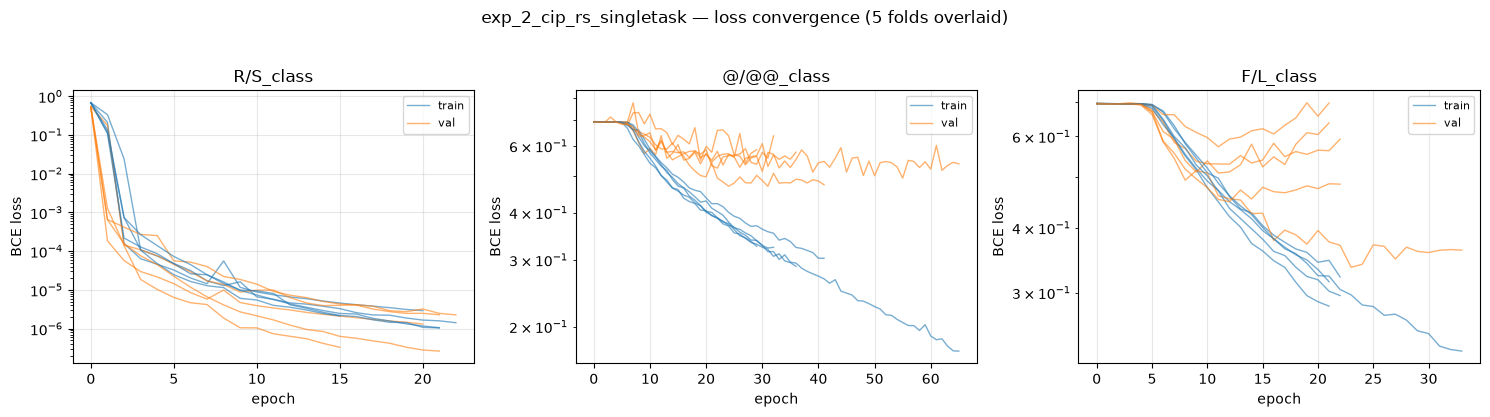

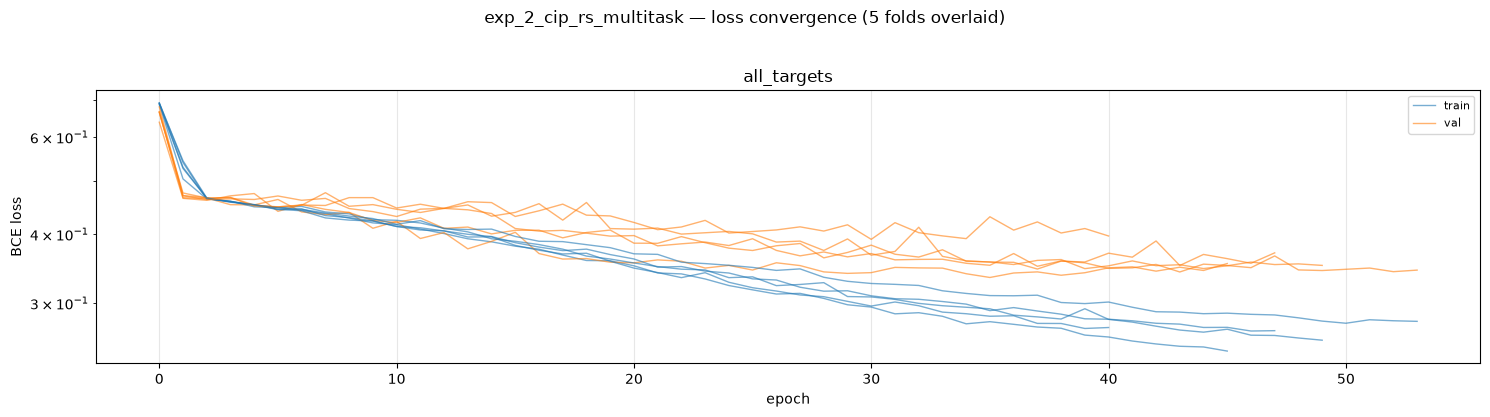

In [23]:
import matplotlib.pyplot as plt

def plot_loss_curves(curves_df, condition, figsize=(15, 4)):
    """Train vs. validation BCE per epoch, one panel per target, folds overlaid."""
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        for fold, g in t.groupby('fold'):
            g = g.sort_values('epoch')
            ax.plot(g['epoch'], g['train_loss_epoch'], alpha=.6, lw=1,
                    color='tab:blue', label='train' if fold == 0 else None)
            ax.plot(g['epoch'], g['val_loss'], alpha=.6, lw=1,
                    color='tab:orange', label='val' if fold == 0 else None)
        ax.set_title(f'{target}')
        ax.set_xlabel('epoch')
        ax.set_ylabel('BCE loss')
        ax.set_yscale('log')
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    n_folds = sub['fold'].nunique()
    fig.suptitle(f'{condition} — loss convergence ({n_folds} '
                 f"fold{'s' if n_folds != 1 else ''} overlaid)", y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_loss_curves(curves_df, cond)
    plt.show()

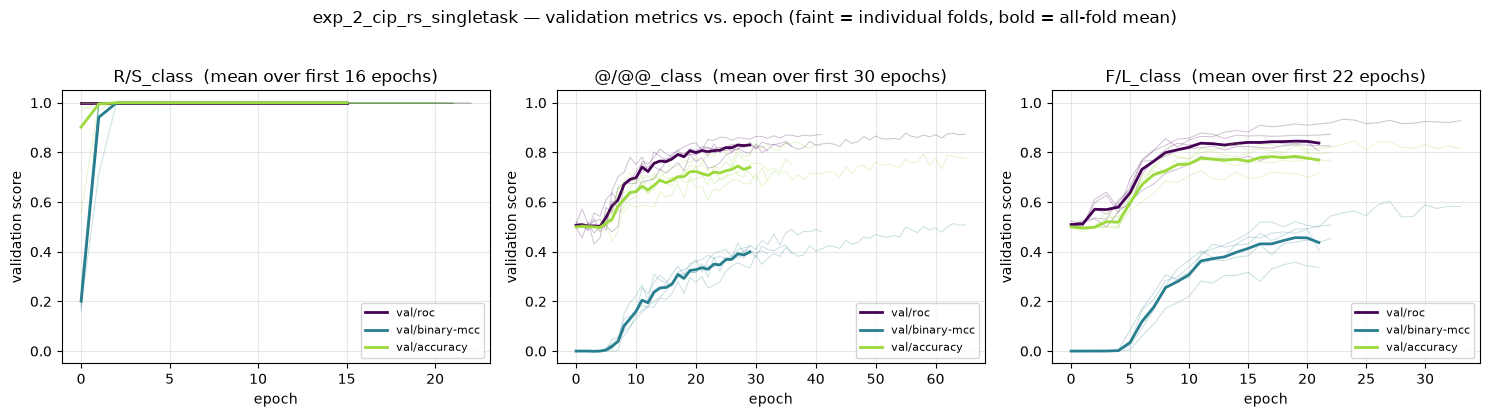

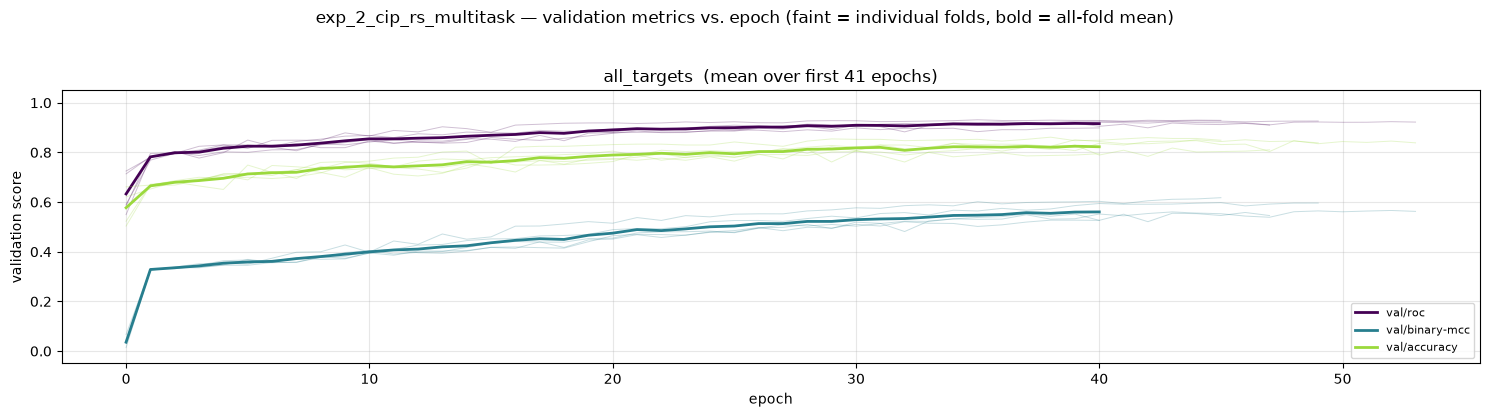

In [24]:
def _fold_mean(t, cols):
    """
    Fold-average `cols` per epoch, but only over epochs where EVERY fold is still training.

    Folds stop at different epochs, so a naive groupby('epoch').mean() silently averages
    over a shrinking subset: the tail of the curve would describe a different (and
    increasingly lucky) population than the head. Returns the complete-fold mean plus the
    fold count so callers can label what was dropped.
    """
    n_per_epoch = t.groupby('epoch')['fold'].nunique()
    n_folds = int(n_per_epoch.max())
    complete = n_per_epoch[n_per_epoch == n_folds].index
    return t[t['epoch'].isin(complete)].groupby('epoch')[cols].mean(), n_folds, len(n_per_epoch) - len(complete)


def plot_metric_curves(curves_df, condition, metrics=('val/roc', 'val/binary-mcc', 'val/accuracy'),
                       figsize=(15, 4)):
    """
    Validation metrics per epoch.

    Mind the mixed semantics of these three curves:
      * `val/roc` is threshold-free.
      * `val/accuracy` is thresholded at 0.5 by torchmetrics.
      * `val/binary-mcc` is NOT thresholded at all — chemprop's BinaryMCCMetric accumulates
        soft confusion counts straight from the probabilities, making it sensitive to
        confidence as well as ranking.
    None of them are comparable to the tuned-threshold metrics in the results CSV.

    Individual folds are drawn faintly; the bold line is the mean over epochs where all
    folds are still training (see `_fold_mean`).
    """
    sub = curves_df[curves_df['featurization'] == condition]
    targets = sub['target'].unique()
    fig, axes = plt.subplots(1, len(targets), figsize=figsize, squeeze=False)
    colors = plt.cm.viridis(np.linspace(0, .85, len(metrics)))

    for ax, target in zip(axes[0], targets):
        t = sub[sub['target'] == target]
        present = [m for m in metrics if m in t.columns]
        mean_df, n_folds, n_dropped = _fold_mean(t, present)
        for metric, color in zip(present, colors):
            for _, g in t.groupby('fold'):          # per-fold, faint
                g = g.sort_values('epoch')
                ax.plot(g['epoch'], g[metric], color=color, lw=.7, alpha=.25)
            ax.plot(mean_df.index, mean_df[metric], color=color, lw=2.0, label=metric)
        ax.set_title(f'{target}' + (f'  (mean over first {len(mean_df)} epochs)' if n_dropped else ''))
        ax.set_xlabel('epoch')
        ax.set_ylabel('validation score')
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    fig.suptitle(f'{condition} — validation metrics vs. epoch '
                 f'(faint = individual folds, bold = all-fold mean)', y=1.03)
    fig.tight_layout()
    return fig


for cond in curves_df['featurization'].unique():
    plot_metric_curves(curves_df, cond)
    plt.show()

### The calibration diagnostic

`val_loss` against `val/roc` on twin axes. Where AUROC saturates while BCE keeps falling,
the model's *ranking* is already perfect and only its *probabilities* are still moving.
That region is why `ModelCheckpoint` must not monitor `val/roc`: a strict `>` comparison
means a saturated AUROC never replaces the saved checkpoint, freezing selection on an
early, uncalibrated epoch.

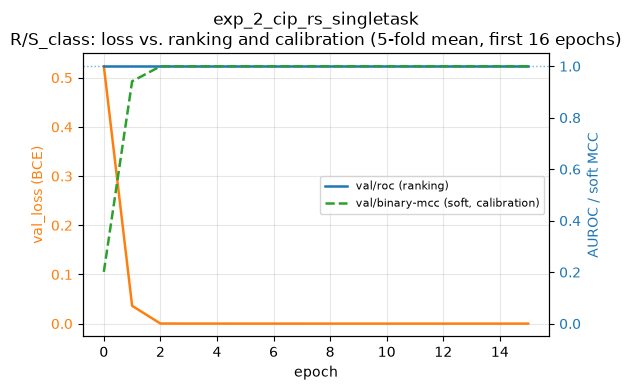

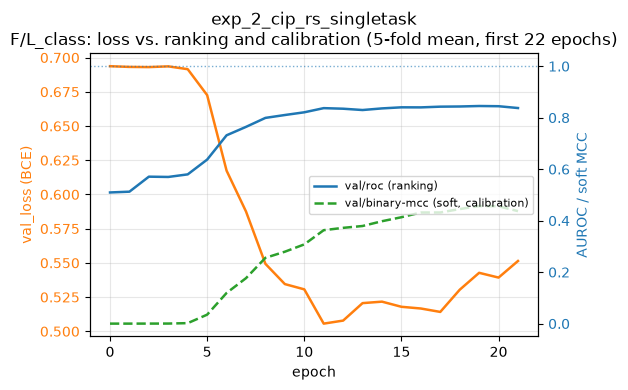

In [25]:
def plot_loss_vs_auroc(curves_df, condition, target, figsize=(6, 4)):
    """
    val_loss against ranking (val/roc) and calibration (soft val/binary-mcc) on twin axes.

    For a target whose AUROC saturates early (R/S), the gap shows that ranking is already
    perfect while the probabilities are still moving — which is why ModelCheckpoint must not
    monitor val/roc: a strict `>` comparison means a saturated AUROC never replaces the
    saved checkpoint. For a target whose AUROC never saturates (F/L), the three curves
    simply improve together.

    Restricted to epochs where all folds are still training (see `_fold_mean`).
    """
    t = curves_df[(curves_df['featurization'] == condition) & (curves_df['target'] == target)]
    cols = [c for c in ('val_loss', 'val/roc', 'val/binary-mcc') if c in t.columns]
    g, n_folds, n_dropped = _fold_mean(t, cols)

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.plot(g.index, g['val_loss'], color='tab:orange', lw=1.8, label='val_loss (BCE)')
    ax1.set_xlabel('epoch')
    ax1.set_ylabel('val_loss (BCE)', color='tab:orange')
    ax1.tick_params(axis='y', labelcolor='tab:orange')

    ax2 = ax1.twinx()
    ax2.plot(g.index, g['val/roc'], color='tab:blue', lw=1.8, label='val/roc (ranking)')
    if 'val/binary-mcc' in g.columns:
        ax2.plot(g.index, g['val/binary-mcc'], color='tab:green', lw=1.8, ls='--',
                 label='val/binary-mcc (soft, calibration)')
    ax2.axhline(1.0, color='tab:blue', ls=':', lw=1, alpha=.6)
    ax2.set_ylabel('AUROC / soft MCC', color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc='center right', fontsize=8)

    ax1.set_title(f'{condition}\n{target}: loss vs. ranking and calibration '
                  f'({n_folds}-fold mean, first {len(g)} epochs)')
    ax1.grid(alpha=.3)
    fig.tight_layout()
    return fig


for _t in ('R/S_class', 'F/L_class'):
    plot_loss_vs_auroc(curves_df, 'exp_2_cip_rs_singletask', _t)
    plt.show()